In [1]:
import bayesflow as bf
import keras
import matplotlib.pyplot as plt
import numpy as np

# reduce image resolution to reduce file size
plt.rcParams["figure.dpi"] = 80

Defaulting to JAX.
To override, set the KERAS_BACKEND environment variable before importing bayesflow.
See: https://keras.io/getting_started/#configuring-your-backend
INFO:2026-03-04 17:48:53,510:jax._src.xla_bridge:834: Unable to initialize backend 'tpu': INTERNAL: Failed to open libtpu.so: libtpu.so: cannot open shared object file: No such file or directory
INFO:jax._src.xla_bridge:Unable to initialize backend 'tpu': INTERNAL: Failed to open libtpu.so: libtpu.so: cannot open shared object file: No such file or directory
INFO:bayesflow:Using backend 'jax'


# Inference on Spatial Data: Inferring the Parameters of Gaussian Random Fields

*Authors:  Valentin Pratz and Niels Bracher*

In this tutorial, we demonstrate how to use BayesFlow with spatial (i.e., image) data. We will demonstrate two common scnearios:

- Inferring low-dimensional parameters from high-dimensional images
- Generating high-dimensional images given low-dimensional parameters

The main challenge when analyzing image data is building suitable backbone networks. The devil lies in the detail.

Lucikly, we can leverage common architectures used in image processing that are readily available in BayesFlow.

As an example, we will take a look at Gaussian random fields (GRFs).
For a nice introduction that also serves as the inspiration for the example below, refer to the article [The Beauty of Gaussian Random Fields](https://structures.uni-heidelberg.de/blog/posts/gaussian-random-fields/index.php) ([archive](https://web.archive.org/web/20250323141017/https://structures.uni-heidelberg.de/blog/posts/gaussian-random-fields/index.php)) by Sara Konrad. Below, we give a short summary that should be sufficient to get the gist of the example.

GRFs describe spatially correlated variables.
For homogeneous and isotropic GRFs, the underlying covariance function does not depend on the position and only depends on the distance, not on the direction.
In that case, the GRF can be completely described by a mean value, which can be set to zero without loss of generality, and the covariance function.
The covariance function can be translated into frequency space using the Fourier transform, giving the *power spectrum* of the covariance function.
This describes the amount of correlation as a function of the wave number $k$.
An interesting example is the power law power spectrum $P(k)=k^{-\alpha}$.
It shows the same behavior on different scales, leading to fractal structures.
The exact behavior is defined by the exponent $\alpha$, which we want to estimate, along with a scaling factor describing the magnitude of the field.

For the simulations, we will use the [FyeldGenerator](https://github.com/cphyc/FyeldGenerator) package ([Zenodo](https://zenodo.org/record/7427712)).

In [10]:
try:
    from FyeldGenerator import generate_field
except ImportError:
    import pip
    pip.main(['install', 'FyeldGenerator'])

The package provides us with the `generate_field` function, which requires a distribution to sample complex values (usually from a standard normal distribution for both real and imaginary part), a power spectrum and the shape of the desired grid. Let's define them and take a look at some examples:

In [11]:
def generate_power_spectrum(alpha, scale):
    def power_spectrum(k):
        return np.power(k, -alpha) * scale**2

    return power_spectrum


def distribution(shape):
    a = np.random.normal(loc=0, scale=np.sqrt(np.prod(shape)), size=shape)
    b = np.random.normal(loc=0, scale=np.sqrt(np.prod(shape)), size=shape)
    return a + 1j * b

In [12]:
power_spectrum = generate_power_spectrum(3.0, 1.0)

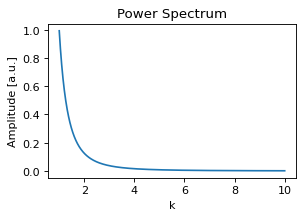

In [13]:
plt.figure(figsize=(4,2.5))
k = np.logspace(0.001, 1, 300)
plt.plot(k, power_spectrum(k))
plt.title("Power Spectrum")
plt.xlabel("k")
plt.ylabel("Amplitude [a.u.]");

Generating a field is internally achieved by sampling random numbers, a few multiplications and a fast Fourier transform, so generating a field is very fast:

In [14]:
%%time
np.random.seed(2025)
field_shape = (64, 64)
field = generate_field(distribution, power_spectrum, field_shape)

CPU times: user 806 μs, sys: 52 μs, total: 858 μs
Wall time: 720 μs


Below, we take a look at the way the patterns change when we change $\alpha$.

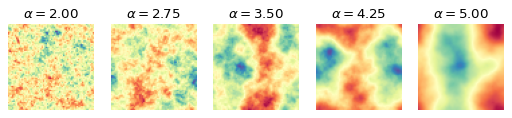

In [16]:
n_examples = 5
alphas = np.linspace(2, 5, n_examples)
log_std = 0
field_shape = (64, 64)
cmap = "Spectral"

fig, axs = plt.subplots(1, n_examples, figsize=(n_examples * 1.6, 1.7))
for alpha, ax in zip(alphas, axs):
    power_spectrum = generate_power_spectrum(alpha, np.exp(log_std))
    field = generate_field(distribution, power_spectrum, field_shape)
    max_magnitude = np.max(np.abs(field))
    ax.imshow(field, cmap=cmap, vmin=-max_magnitude, vmax=max_magnitude)
    ax.set_title(f"$\\alpha={alpha:.2f}$")
    ax.set_axis_off()

The difference is clearly visible, as the structures become more homogeneous as $\alpha$ increases.
The task is now for the summary network to learn relevant summary statistics from the images that enable the inference model to determine the correct parameter values.

## Simulator

We define a simple prior for the parameters and wrap the `generate_field` function to generate data in the desired structure.

In [17]:
rng = np.random.default_rng()


def prior():
    return {"log_std": rng.normal(), "alpha": rng.normal(loc=4, scale=0.5)}


def likelihood(log_std, alpha, field_shape=(64, 64)):
    field = generate_field(
        distribution, generate_power_spectrum(alpha, np.exp(log_std)), field_shape
    )

    return {"field": field[..., None]}


simulator = bf.make_simulator([prior, likelihood])

We can quickly check that the output shapes of the simulator match our expectations:

In [18]:
keras.tree.map_structure(keras.ops.shape, simulator.sample(3))

{'log_std': (3, 1), 'alpha': (3, 1), 'field': (3, 64, 64, 1)}

## Summary Network

As we have translation-invariant images, [convolutional neural networks (CNNs)](https://en.wikipedia.org/wiki/Convolutional_neural_network) are a natural choice as summary networks.
We currently provide the `ResNet` class in our experimental module, which implements a CNN architecture.
Each residual layer produces an output which divides the side length of the image by two.
The `widths` argument describes the number of *channels* the layer produces.
The `ResNet` does not handle to post-processing of the outputs, which consists of flattening and an additional dense layer, followed by a projection to the desired number of summary dimensions. In the class below, we inherit from `SummaryNetwork` and perform those steps, making the `ResNet` usable as a summary network.

In [19]:
import bayesflow.experimental.resnet


bf.utils.serialization.serializable("custom")


class ResNetSummaryNetwork(bf.networks.SummaryNetwork):
    def __init__(
        self,
        summary_dim,
        widths,
        num_fully_connected=64,
        dropout=0.0,
        use_batchnorm=False,
        **kwargs,
    ):
        """
        Create a ResNet summary network with a final dense layer.

        Parameters
        ----------
        summary_dim : int
            The dimension of the summary statistics.
        widths : Sequence of int
            The number of channels in the convolutional layers.
        num_fully_connected : int, optional
            The number of units in the fully connected layer (default is 64).
        dropout : float, optional
            Dropout probability in the residual layers (default is 0.0).
        use_batchnorm : bool, optional
            Use batch normalization in the residual layers (default is False).
        kwargs : dict, optional
            Additional keyword arguments for the tf.keras.Model superclass.
        """
        super().__init__(**kwargs)
        self.summary_dim = summary_dim

        layers = []
        layers.append(
            bf.experimental.resnet.ResNet(
                widths, use_batchnorm=use_batchnorm, dropout=dropout
            )
        )
        layers.append(keras.layers.Flatten())
        layers.append(keras.layers.Dense(num_fully_connected, activation="relu"))
        layers.append(keras.layers.Dense(summary_dim))

        self.net = bf.networks.Sequential(layers)

    def call(self, inputs, training: bool = False, **kwargs):
        return self.net(inputs)

## Training

We will use online training, i.e., simulate the training data on the fly, but we already generate the validation data and test data:

In [20]:
%%time
validation_data = simulator.sample(100)

CPU times: user 19.8 ms, sys: 7.99 ms, total: 27.7 ms
Wall time: 27.5 ms


In [21]:
%%time
test_data = simulator.sample(1000)

CPU times: user 231 ms, sys: 19.9 ms, total: 251 ms
Wall time: 251 ms


We now create the summary network and the workflow object we use for training. Enabling dropout seems to cause problems during evaluation, so we disable it here.

In [22]:
summary_network = ResNetSummaryNetwork(
    summary_dim=6, widths=[8, 16, 32, 64, 128], num_fully_connected=128, dropout=0.0
)

workflow = bf.workflows.BasicWorkflow(
    simulator=simulator,
    summary_network=summary_network,
    inference_variables=["log_std", "alpha"],
    summary_variables=["field"],
    standardize="all",
)

Now we are ready to start the online training. For detailed output during training, remove the `verbose=2` argument.
For better results, try to increase the number of epochs.

As we use convolutional layers, training can be quite slow on a CPU (10-15 minutes for 10 epochs), and using a GPU can significantly speed up training (< 1 minute).

In [23]:
history = workflow.fit_online(
    num_batches_per_epoch=1000,
    validation_data=validation_data,
    batch_size=32,
    epochs=10,
    verbose=2,
)

INFO:bayesflow:Fitting on dataset instance of OnlineDataset.
INFO:bayesflow:Building on a test batch.


Epoch 1/10
1000/1000 - 30s - 30ms/step - loss: 1.0660 - val_loss: 0.1040
Epoch 2/10
1000/1000 - 12s - 12ms/step - loss: 0.0411 - val_loss: -2.1988e-02
Epoch 3/10
1000/1000 - 12s - 12ms/step - loss: -5.3559e-01 - val_loss: -8.1810e-01
Epoch 4/10
1000/1000 - 12s - 12ms/step - loss: -8.7196e-01 - val_loss: -7.6103e-01
Epoch 5/10
1000/1000 - 12s - 12ms/step - loss: -1.0840e+00 - val_loss: -1.2093e+00
Epoch 6/10
1000/1000 - 12s - 12ms/step - loss: -1.2462e+00 - val_loss: -1.5052e+00
Epoch 7/10
1000/1000 - 13s - 13ms/step - loss: -1.4843e+00 - val_loss: -1.8302e+00
Epoch 8/10
1000/1000 - 13s - 13ms/step - loss: -1.7355e+00 - val_loss: -2.0006e+00
Epoch 9/10
1000/1000 - 12s - 12ms/step - loss: -1.8840e+00 - val_loss: -2.0766e+00
Epoch 10/10
1000/1000 - 12s - 12ms/step - loss: -1.9727e+00 - val_loss: -2.1059e+00


INFO:bayesflow:Training completed in 2.48 minutes.


## Evaluation

Finally, we can plot the diagnostics. They show good recovery and calibration, indicating successful training.

Sampling:   0%|          | 0/1 [00:00<?, ?batch/s]

{'recovery': <Figure size 800x400 with 2 Axes>,
 'calibration': <Figure size 800x400 with 2 Axes>}

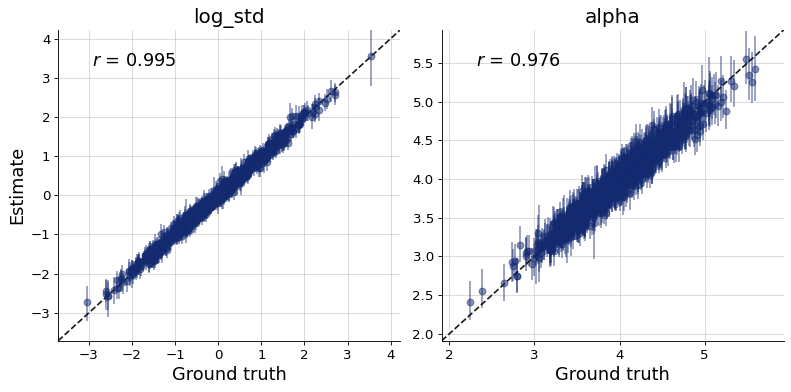

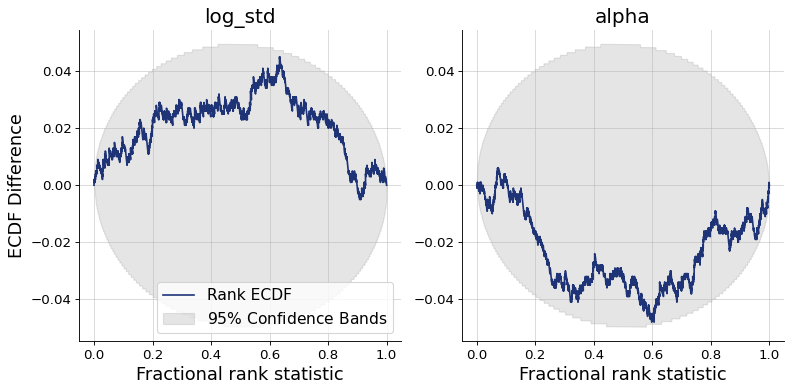

In [24]:
figs = workflow.plot_custom_diagnostics(
    test_data=test_data,
    plot_fns={
        "recovery": bf.diagnostics.recovery,
        "calibration": bf.diagnostics.calibration_ecdf,
    },          
)

# Inference of Spatial Parameters: Generating Gaussian Random Fields

In the following we will turn the task around: create fields given the field parameters.

## Simulator

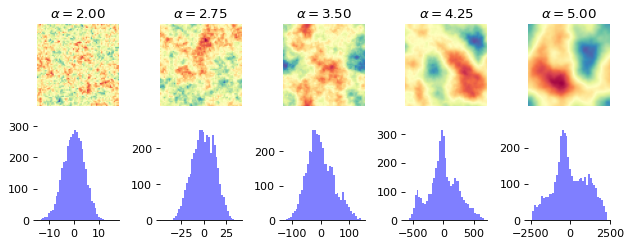

In [26]:
fig, axs = plt.subplots(2, n_examples, figsize=(n_examples * 1.6, 1.9*1.7))
for a, alpha in enumerate(alphas):
    power_spectrum = generate_power_spectrum(alpha, np.exp(log_std))
    field = generate_field(distribution, power_spectrum, field_shape)
    max_magnitude = np.max(np.abs(field))
    axs[0, a].imshow(field, cmap=cmap, vmin=-max_magnitude, vmax=max_magnitude)
    axs[0, a].set_title(f"$\\alpha={alpha:.2f}$")
    axs[0, a].set_axis_off()

    axs[1, a].hist(field.flatten(), bins=40, color="blue", alpha=0.5)
    axs[1, a].spines[["left", "right", "top"]].set_visible(False)

plt.tight_layout()

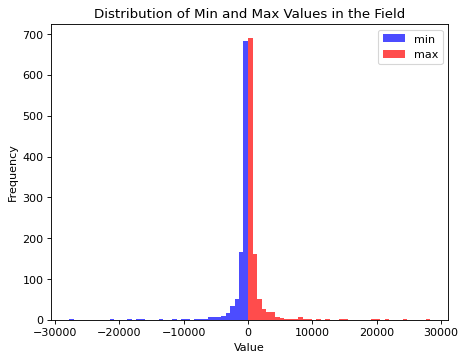

In [28]:
samples = simulator.sample(1000)
plt.figure()
plt.hist(samples["field"].min(axis=(1, 2)).flatten(), bins=40, color="blue", alpha=0.7)
plt.hist(samples["field"].max(axis=(1, 2)).flatten(), bins=40, color="red", alpha=0.7)
plt.legend(["min", "max"])
plt.title("Distribution of Min and Max Values in the Field")
plt.xlabel("Value")
plt.ylabel("Frequency")
plt.show()

Field values span an extreme range with the current definition of the simulator. The learnable standardization preprocessing of BayesFlow would still allow to proceede from here. Though, given that we are interested in the structure certain parameter values generate, we will modify the simulator by adjusting the field length scale to a given $\alpha$ value dynamically. This leads to a more similar field value range for the prior over $\alpha$ values but does not change the underlying structure of the fields.

In [29]:
rng = np.random.default_rng(seed=42)

def distribution(shape):
    a = rng.normal(loc=0, scale=1., size=shape)
    b = rng.normal(loc=0, scale=1., size=shape)
    return a + 1j * b

def prior():
    log_std = rng.normal(scale=0.3)
    alpha = rng.normal(loc=3, scale=0.5)
    params_expanded = np.array([log_std, alpha])
    params_expanded = np.ones(field_shape + (2,)) * params_expanded[None, None, :]
    return {
        "log_std": log_std,
        "alpha": alpha,
        "params_expanded": params_expanded
    }

def likelihood(log_std, alpha, field_shape=(64, 64)):
    field = generate_field(
        distribution, generate_power_spectrum(alpha, np.exp(log_std)), field_shape, unit_length=1/(np.abs(alpha) + 1e-7)
    )

    return {"field": field[..., None]}

simulator = bf.make_simulator([prior, likelihood])

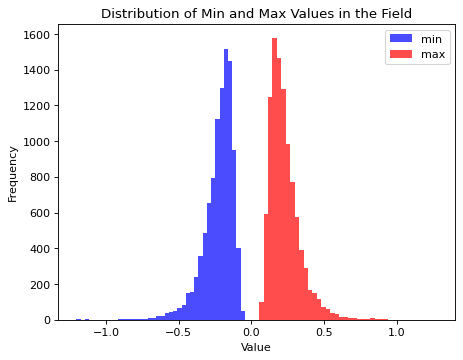

In [30]:
samples = simulator.sample(10000)
plt.figure()
plt.hist(samples["field"].min(axis=(1, 2)).flatten(), bins=40, color="blue", alpha=0.7)
plt.hist(samples["field"].max(axis=(1, 2)).flatten(), bins=40, color="red", alpha=0.7)
plt.legend(["min", "max"])
plt.title("Distribution of Min and Max Values in the Field")
plt.xlabel("Value")
plt.ylabel("Frequency")
plt.show()

## Inference Network
For the inference network we can pick one from the following configurations (feel free to explore them all):

In [40]:
adapter = (
    bf.adapters.Adapter()
    .convert_dtype("float64", "float32")
    .rename("params_expanded", "inference_conditions")
    .rename("field", "inference_variables")
)

configs = {
    "UNet": {
        "widths": (64, 128, 256, 512),
        "res_blocks": 2,
        "attn_stage": None,
    },
    "UViT": {
        "widths": (64, 128, 256),
        "res_blocks": 3,
        "transformer_blocks": 2,
        "transformer_dropout": 0.2,
        "transformer_width": 512,
    },
    "ResidualUViT": {
        "widths": (64, 128, 256),
        "res_blocks_up": 2,
        "res_blocks_down": 3,
        "transformer_blocks": 2,
        "transformer_dropout": 0.2,
        "transformer_width": 512,
    }
}

## Training

The code below will be very slow on CPU. You definitely need a GPU if you are interested in image generation. Below, we demonstrate a diffu

In [41]:
diffusion = bf.networks.DiffusionModel(
    subnet=bf.networks.ResidualUViT,
    subnet_kwargs=configs["ResidualUViT"],
    prediction_type="velocity",
    noise_schedule="cosine",
)

workflow = bf.workflows.BasicWorkflow(
    simulator=simulator,
    inference_network=diffusion,
    adapter=adapter,
    standardize="inference_conditions",
    initial_learning_rate=1e-4,
)

In [ ]:
history = workflow.fit_online(
    epochs=10,
    batch_size=32,
    num_batches_per_epoch=1000,
    validation_data=100
)

In [ ]:
f = bf.diagnostics.plots.loss(history)

## Evaluation

We can briefly take a look at a few test images and corresponding generated images:

Sampling:   0%|          | 0/1 [00:00<?, ?batch/s]

INFO:bayesflow:Sampling completed in 5.94 seconds.


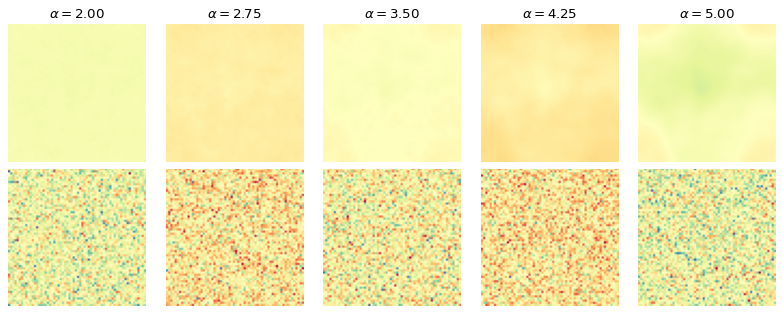

In [35]:
def plot_distribution(shape):
    rng = np.random.default_rng(seed=1234123)
    a = rng.normal(loc=0, scale=1., size=shape)
    b = rng.normal(loc=0, scale=1., size=shape)
    return a + 1j * b

simulator_spectra = [generate_power_spectrum(alpha, np.exp(log_std)) for alpha in alphas]
fields_simulated = np.stack([generate_field(plot_distribution, spectra, field_shape, unit_length=1/(np.abs(alpha) + 1e-7)) for (alpha, spectra) in zip(alphas, simulator_spectra)], axis=0)
params_expanded = []
for alpha in alphas:
    param_expanded = np.array([log_std, alpha])
    params_expanded.append(np.ones(field_shape + (2,)) * param_expanded[None, None, :])
params_expanded = np.stack(params_expanded, axis=0)

fields_generated = workflow.sample(num_samples=1, conditions={"params_expanded": params_expanded})["field"][:, 0]

fig, axs = plt.subplots(2, n_examples, figsize=(n_examples * 2, 4))

for i, (field_gen, field_sim, alpha) in enumerate(zip(fields_generated, fields_simulated, alphas)):
    a = axs[0, i].imshow(field_sim, cmap=cmap, vmin=np.minimum(field_sim.min(), field_gen.min()), vmax=np.maximum(field_sim.max(), field_gen.max()))
    axs[0, i].set_title(rf"$\alpha={alpha:.2f}$")
    b = axs[1, i].imshow(field_gen[:, :, 0], cmap=cmap, vmin=np.minimum(field_sim.min(), field_gen.min()), vmax=np.maximum(field_sim.max(), field_gen.max()))

for ax in axs.flat:
    ax.set_axis_off()
    ax.set_aspect("equal")
plt.tight_layout()
plt.show()